stt742, sc68468

**Part 1: Data Ingestion**


Load library


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from dateutil import parser

Load and view data sets


In [3]:
file_path = 'gs://adult_income_cs329e/prim/adult.csv'
adult = pd.read_csv(file_path, encoding='latin-1')
adult.columns = ['age', 'workclass', 'fnlwght', 'education',
'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex',
'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

In [4]:
file_path = 'gs://adult_income_cs329e/suppl/countries of the world.csv'
sup_countries = pd.read_csv(file_path, encoding='latin-1')
sup_countries.columns = ['country', 'region', 'population', 'area', 'population_density', 'coastline',
'net_migration', 'infant_mortality', 'gdp_per_capita', 'literacy', 'phone', 'arable', 'crops', 'other',
 'climate', 'birthrate', 'deathrate', 'agriculture', 'industry', 'service']


**Part 2: Initial inspection of datasets**

In [ ]:
adult.columns

Index(['age', 'workclass', 'fnlwght', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [ ]:
adult.dtypes

,0
age,int64
workclass,object
fnlwght,int64
education,object
education_num,int64
marital_status,object
occupation,object
relationship,object
race,object
sex,object


In [ ]:
sup_countries.columns

Index(['country', 'region', 'population', 'area', 'population_density',
       'coastline', 'net_migration', 'infant_mortality', 'gdp_per_capita',
       'literacy', 'phone', 'arable', 'crops', 'other', 'climate', 'birthrate',
       'deathrate', 'agriculture', 'industry', 'service'],
      dtype='object')

In [ ]:
sup_countries.dtypes

,0
country,object
region,object
population,int64
area,int64
population_density,object
coastline,object
net_migration,object
infant_mortality,object
gdp_per_capita,float64
literacy,object


Data sets' information


In [ ]:
adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwght         32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
sup_countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             227 non-null    object 
 1   region              227 non-null    object 
 2   population          227 non-null    int64  
 3   area                227 non-null    int64  
 4   population_density  227 non-null    object 
 5   coastline           227 non-null    object 
 6   net_migration       224 non-null    object 
 7   infant_mortality    224 non-null    object 
 8   gdp_per_capita      226 non-null    float64
 9   literacy            209 non-null    object 
 10  phone               223 non-null    object 
 11  arable              225 non-null    object 
 12  crops               225 non-null    object 
 13  other               225 non-null    object 
 14  climate             205 non-null    object 
 15  birthrate           224 non-null    object 
 16  deathrat

In [ ]:
adult.index

RangeIndex(start=0, stop=32561, step=1)

In [ ]:
sup_countries.index

RangeIndex(start=0, stop=227, step=1)


Samples

In [ ]:
adult.head()

,age,workclass,fnlwght,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
adult.tail()

,age,workclass,fnlwght,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
adult.sample(5)

,age,workclass,fnlwght,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
20066,36,?,214896,9th,5,Divorced,?,Unmarried,White,Female,0,0,40,Mexico,<=50K
14898,53,Private,224894,5th-6th,3,Married-civ-spouse,Priv-house-serv,Wife,Black,Female,0,0,10,Haiti,<=50K
16948,71,State-gov,100063,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,Black,Male,0,0,40,United-States,<=50K
22844,66,Self-emp-not-inc,97847,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,United-States,<=50K
2172,48,Self-emp-not-inc,328606,Prof-school,15,Divorced,Prof-specialty,Unmarried,White,Male,14084,0,63,United-States,>50K


In [ ]:
sup_countries.head()

,country,region,population,area,population_density,coastline,net_migration,infant_mortality,gdp_per_capita,literacy,phone,arable,crops,other,climate,birthrate,deathrate,agriculture,industry,service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,"48,0","0,00","23,06","163,07",700.0,"36,0","3,2","12,13","0,22","87,65",1,"46,6","20,34","0,38","0,24","0,38"
1,Albania,EASTERN EUROPE,3581655,28748,"124,6","1,26","-4,93","21,52",4500.0,"86,5","71,2","21,09","4,42","74,49",3,"15,11","5,22","0,232","0,188","0,579"
2,Algeria,NORTHERN AFRICA,32930091,2381740,"13,8","0,04","-0,39",31,6000.0,"70,0","78,1","3,22","0,25","96,53",1,"17,14","4,61","0,101","0,6","0,298"
3,American Samoa,OCEANIA,57794,199,"290,4","58,29","-20,71","9,27",8000.0,"97,0","259,5",10,15,75,2,"22,46","3,27",NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,"152,1","0,00","6,6","4,05",19000.0,"100,0","497,2","2,22",0,"97,78",3,"8,71","6,25",NaN,NaN,NaN


In [ ]:
sup_countries.tail()

,country,region,population,area,population_density,coastline,net_migration,infant_mortality,gdp_per_capita,literacy,phone,arable,crops,other,climate,birthrate,deathrate,agriculture,industry,service
222,West Bank,NEAR EAST,2460492,5860,"419,9","0,00","2,98","19,62",800.0,NaN,"145,2","16,9","18,97","64,13",3,"31,67","3,92","0,09","0,28","0,63"
223,Western Sahara,NORTHERN AFRICA,273008,266000,"1,0","0,42",NaN,NaN,NaN,NaN,NaN,"0,02",0,"99,98",1,NaN,NaN,NaN,NaN,"0,4"
224,Yemen,NEAR EAST,21456188,527970,"40,6","0,36",0,"61,5",800.0,"50,2","37,2","2,78","0,24","96,98",1,"42,89","8,3","0,135","0,472","0,393"
225,Zambia,SUB-SAHARAN AFRICA,11502010,752614,"15,3","0,00",0,"88,29",800.0,"80,6","8,2","7,08","0,03","92,9",2,41,"19,93","0,22","0,29","0,489"
226,Zimbabwe,SUB-SAHARAN AFRICA,12236805,390580,"31,3","0,00",0,"67,69",1900.0,"90,7","26,8","8,32","0,34","91,34",2,"28,01","21,84","0,179","0,243","0,579"


In [ ]:
sup_countries.sample(5)

,country,region,population,area,population_density,coastline,net_migration,infant_mortality,gdp_per_capita,literacy,phone,arable,crops,other,climate,birthrate,deathrate,agriculture,industry,service
174,St Pierre & Miquelon,NORTHERN AMERICA,7026,242,"29,0","49,59","-4,86","7,54",6900.0,"99,0","683,2","13,04",0,"86,96",NaN,"13,52","6,83",NaN,NaN,NaN
125,Malawi,SUB-SAHARAN AFRICA,13013926,118480,"109,8","0,00",0,"103,32",600.0,"62,7","7,9","23,38","1,49","75,13",2,"43,13","19,33","0,342","0,158","0,499"
215,Uruguay,LATIN AMER. & CARIB,3431932,176220,"19,5","0,37","-0,32","11,95",12800.0,"98,0","291,4","7,43","0,23","92,34",3,"13,91","9,05","0,093","0,311","0,596"
39,Central African Rep.,SUB-SAHARAN AFRICA,4303356,622984,"6,9","0,00",0,91,1100.0,"51,0","2,3","3,1","0,14","96,76",2,"33,91","18,65","0,55","0,2","0,25"
158,Panama,LATIN AMER. & CARIB,3191319,78200,"40,8","3,18","-0,91","20,47",6300.0,"92,6","137,9","7,36","1,98","90,66",2,"21,74","5,36","0,068","0,156","0,776"


Summarize the central tendency

In [ ]:
adult.describe(include='all')

,age,workclass,fnlwght,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [ ]:
sup_countries.describe(include='all')

,country,region,population,area,population_density,coastline,net_migration,infant_mortality,gdp_per_capita,literacy,phone,arable,crops,other,climate,birthrate,deathrate,agriculture,industry,service
count,227,227,2.270000e+02,2.270000e+02,227,227,224,224,226.000000,209,223,225,225,225,205,224,223,212,211,212
unique,227,11,NaN,NaN,219,151,157,220,NaN,140,214,203,162,209,6,220,201,150,155,167
top,Afghanistan,SUB-SAHARAN AFRICA,NaN,NaN,"13,8","0,00",0,"9,95",NaN,"99,0","7,9",0,0,100,2,"20,48","6,25","0,01","0,17","0,684"
freq,1,51,NaN,NaN,2,44,62,3,NaN,13,2,9,28,8,111,2,2,8,4,5
mean,NaN,NaN,2.874028e+07,5.982270e+05,NaN,NaN,NaN,NaN,9689.823009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,1.178913e+08,1.790282e+06,NaN,NaN,NaN,NaN,10049.138513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,7.026000e+03,2.000000e+00,NaN,NaN,NaN,NaN,500.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.376240e+05,4.647500e+03,NaN,NaN,NaN,NaN,1900.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.786994e+06,8.660000e+04,NaN,NaN,NaN,NaN,5550.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,1.749777e+07,4.418110e+05,NaN,NaN,NaN,NaN,15700.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Part 3: Plot feature distributions**

<Axes: xlabel='income', ylabel='count'>

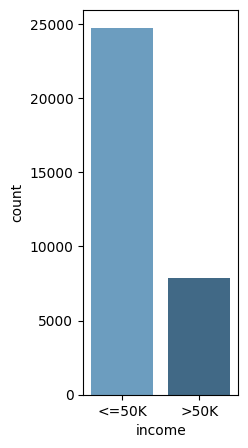

In [ ]:
#income
plt.figure(figsize=(2, 5))
sns.countplot(x='income', data=adult,
              palette='Blues_d',
              hue='income',
              legend=False)

<Axes: xlabel='education_num', ylabel='Count'>

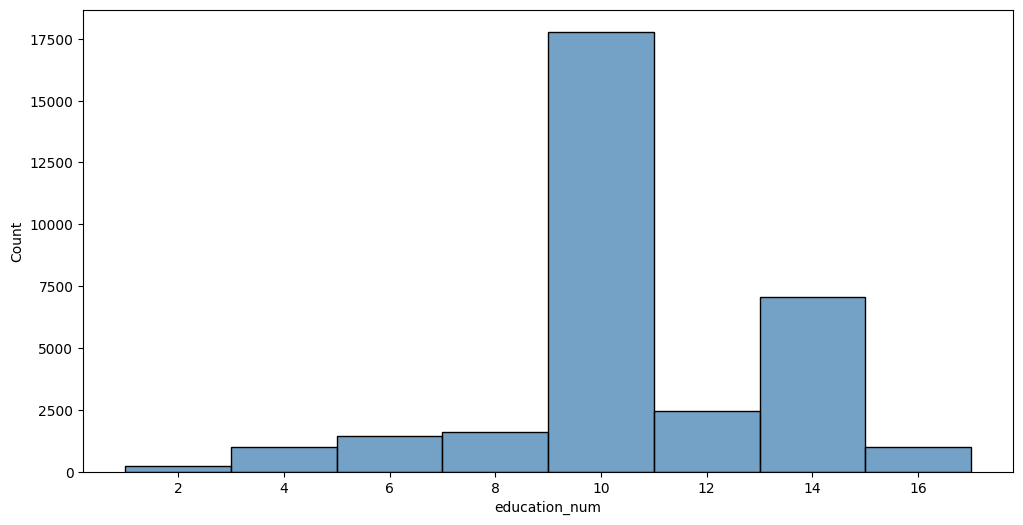

In [6]:
# years of education grouped by range
bins = [1, 3, 5, 7, 9, 11, 13, 15, 17]
plt.figure(figsize=(12, 6))
sns.histplot(data=adult, x='education_num', bins=bins, color='steelblue', kde=False)

<Axes: xlabel='workclass', ylabel='count'>

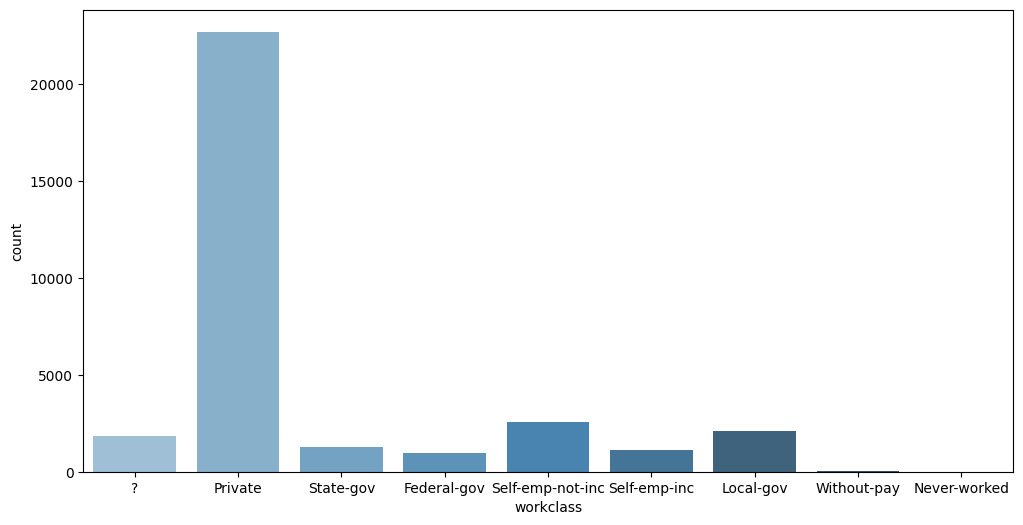

In [ ]:
# working classification by type
plt.figure(figsize=(12, 6))
sns.countplot(x='workclass', data=adult,
              palette='Blues_d',
              hue='workclass',
              legend=False)

<Axes: xlabel='sex', ylabel='count'>

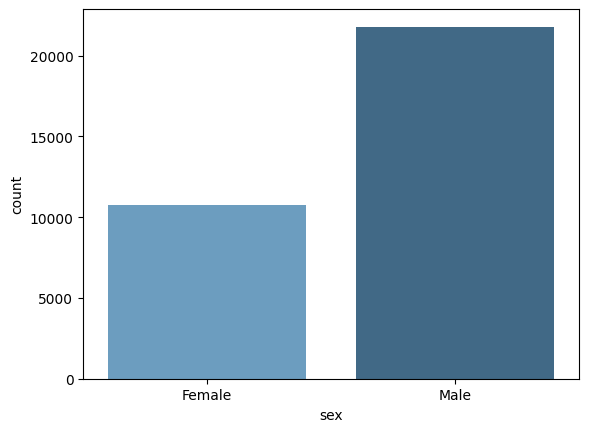

In [ ]:
# gender
sns.countplot(x='sex', data=adult,
              palette='Blues_d',
              hue='sex',
              legend=False)

<Axes: xlabel='hours_per_week', ylabel='Count'>

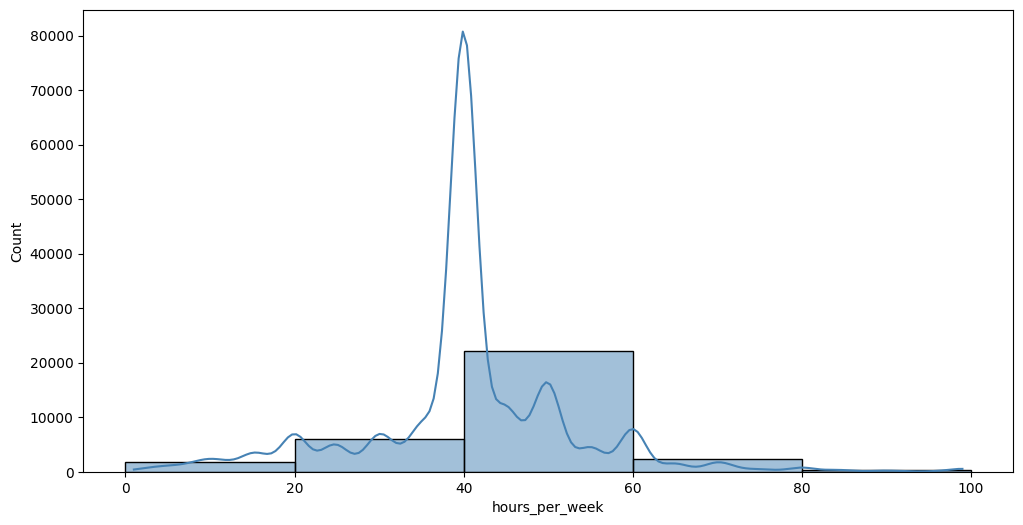

In [7]:
# working hours per week grouped by range
bins = [0, 20, 40, 60, 80, 100]
plt.figure(figsize=(12, 6))
sns.histplot(data=adult, x='hours_per_week', bins=bins, color='steelblue', kde=True)

<Axes: xlabel='race', ylabel='count'>

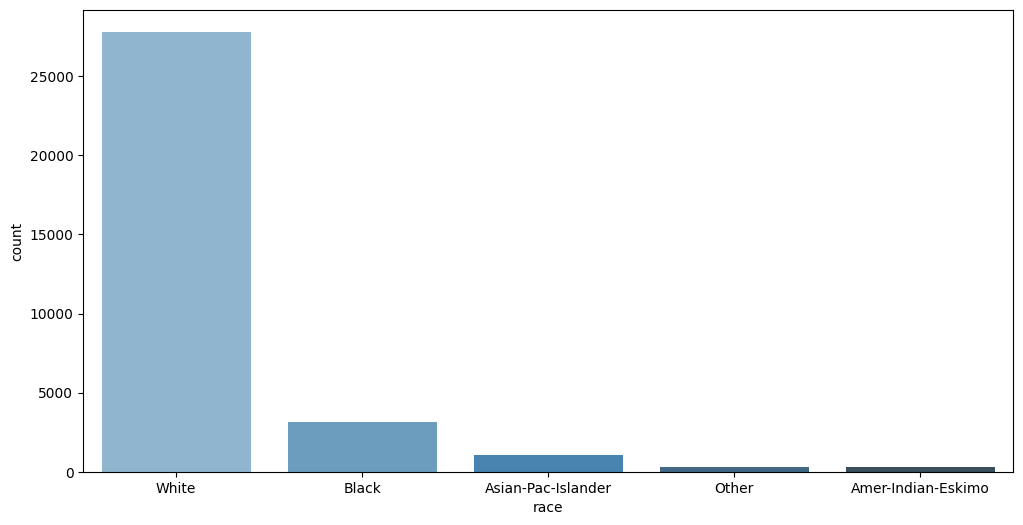

In [ ]:
# race
plt.figure(figsize=(12, 6))
sns.countplot(x='race', data=adult,
              palette='Blues_d',
              hue='race',
              legend=False)

<Axes: xlabel='native_country_grouped', ylabel='count'>

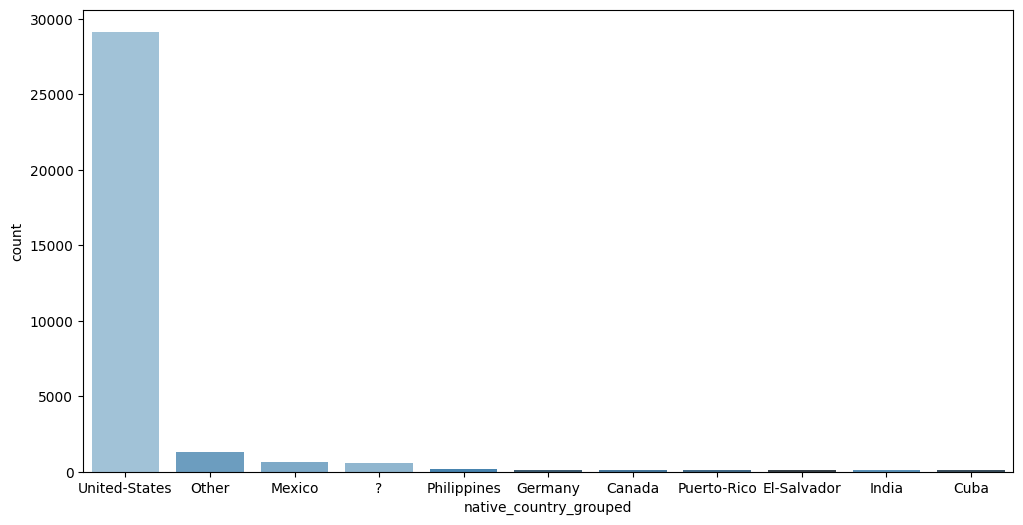

In [ ]:
# native country - with top 10 highlighted
top_ten = 10
top_countries = adult['native_country'].value_counts().nlargest(top_ten).index

adult['native_country_grouped'] = adult['native_country'].where(adult['native_country'].isin(top_countries), other='Other')
plt.figure(figsize=(12, 6))
sns.countplot(x ='native_country_grouped',
              data=adult,
              palette='Blues_d',
              hue = 'native_country_grouped',
              order=adult['native_country_grouped'].value_counts().index)

<Axes: xlabel='lit_range', ylabel='count'>

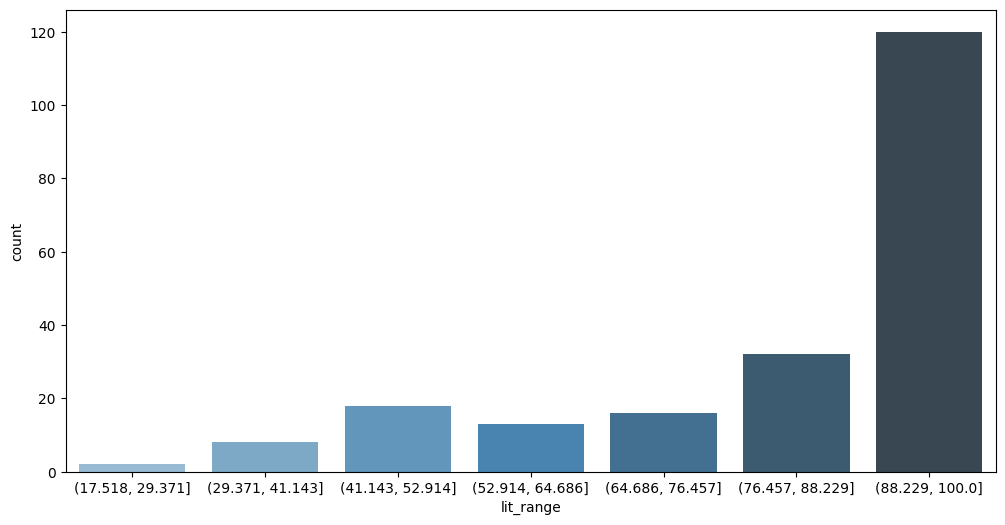

In [ ]:
#literacy percentage grouped by range
sup_countries['lit_range'] = pd.cut(sup_countries['literacy'].str.replace(',', '.').astype(float), bins=7)
plt.figure(figsize=(12, 6))
sns.countplot(x='lit_range', data=sup_countries,
              palette='Blues_d',
              hue='lit_range',
              legend=False)

<Axes: xlabel='pop_range', ylabel='count'>

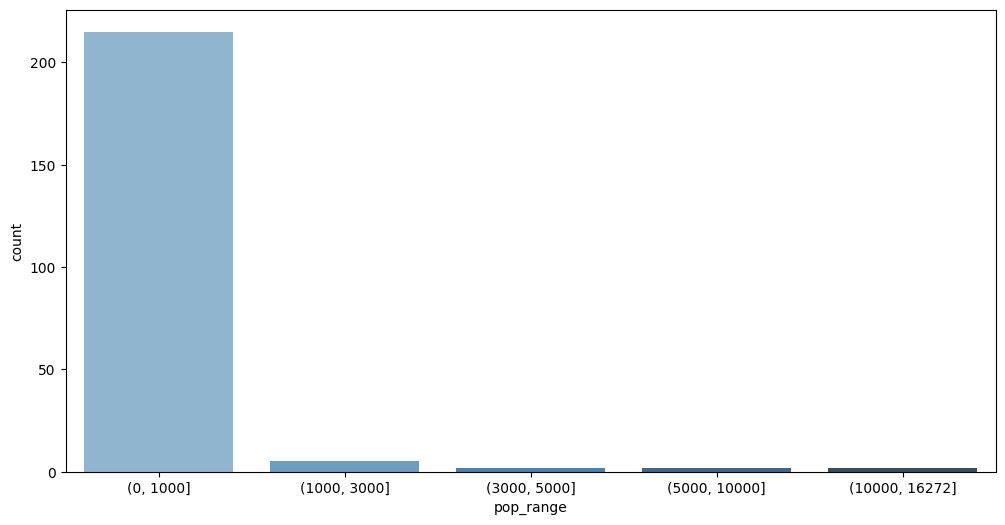

In [ ]:
#population density grouped by range
sup_countries['pop_range'] = pd.cut(sup_countries['population_density'].str.replace(',', '.').astype(float), bins=[0, 1000, 3000, 5000, 10000, 16272])
plt.figure(figsize=(12, 6))
sns.countplot(x='pop_range', data=sup_countries,
              palette='Blues_d',
              hue='pop_range',
              legend=False)

<Axes: xlabel='gdp_per_capita', ylabel='Count'>

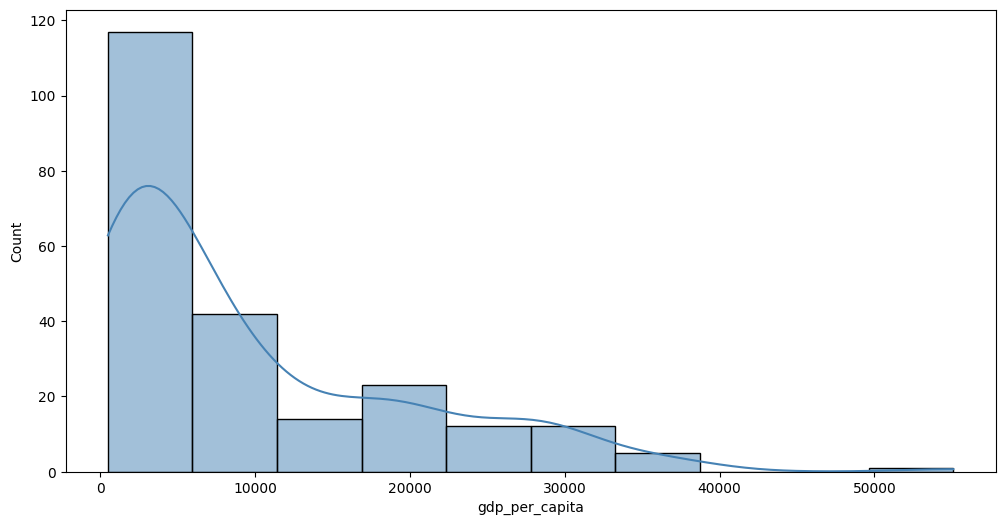

In [5]:
#gdp per capita grouped by range
plt.figure(figsize=(12, 6))
sns.histplot(data=sup_countries, x='gdp_per_capita', bins=10, kde=True, color='steelblue')
